<a href="https://colab.research.google.com/github/Nawaf-Alorabi/Tw_ML_Predicting_Employee_Burnout_with_Regression/blob/main/nawaf_KerasTuner_Recall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Nawaf-Alorabi/Tw_Customer_Churn_Prediction_System_DeepLearn/blob/main/Faisal_churn_prediction_ann_h5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Prediction — ANN (Binary Classification)

## 1. Problem Definition

**Objective:** Predict whether a customer will leave (churn) a telecom service using an Artificial Neural Network.

**Dataset:** [Telco Customer Churn (IBM / Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7,043 records × 21 features.

**Approach:**
- Build a **baseline ANN** → identify weaknesses (low recall)
- Build an **advanced ANN** with regularization (L2, Dropout, Early Stopping), class weighting, and manual hyperparameter tuning
- Compare baseline vs advanced model on Accuracy, Precision, Recall, F1, ROC-AUC
- Save the best model and create an inference function

**Author:** Faisal

## 2. Imports & Setup

In [ ]:
# =========================
# IMPORTS
# =========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

## 3. Data Loading & Exploration

In [ ]:
url = "https://raw.githubusercontent.com/Nawaf-Alorabi/Tw_Customer_Churn_Prediction_System_DeepLearn/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Shape:", df.shape)

Shape: (7043, 21)


In [ ]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [ ]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


##  Churn Distribution Analysis


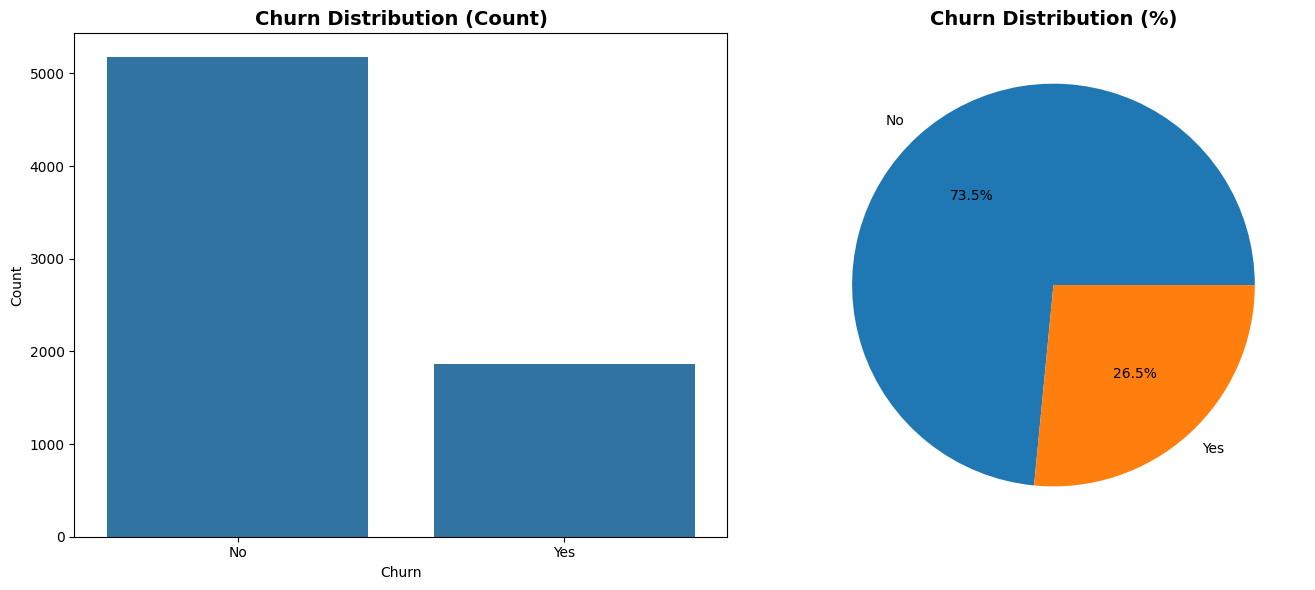

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ======================
# Bar Plot
# ======================
sns.countplot(x="Churn", data=df, ax=axes[0])
axes[0].set_title("Churn Distribution (Count)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")

# ======================
# Pie Chart
# ======================
df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[1]
)
axes[1].set_title("Churn Distribution (%)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Correlation Heatmap

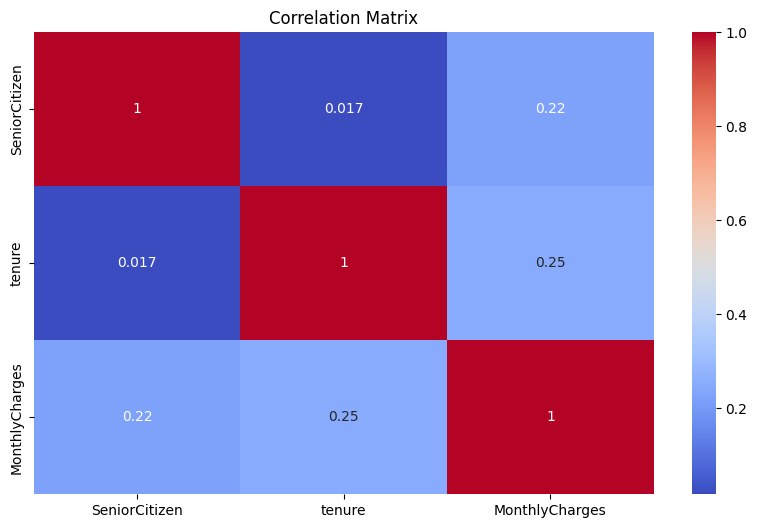

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## 4. Data Preprocessing

In [ ]:
# ================================
# DATA PREPROCESSING
# ================================


# 1) Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# 2) Drop useless column
df.drop("customerID", axis=1, inplace=True)

# 3) Convert target to 0/1
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# 4) Convert binary categorical columns to 0/1
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "gender"]

for col in binary_cols:
    df[col] = df[col].map({
        "No": 0, "Yes": 1,
        "Female": 0, "Male": 1
    })

# 5) Replace service-related special labels
replace_cols = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies"
]

for col in replace_cols:
    df[col] = df[col].replace({
        "No internet service": "No",
        "No phone service": "No"
    })

# 6) Feature engineering
df["AvgCharge"] = df["TotalCharges"] / (df["tenure"] + 1)

# 7) One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# 8) Convert boolean columns to 0/1
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

# 9) Apply scaling only to continuous numerical columns
scale_cols = ["tenure", "MonthlyCharges", "TotalCharges", "AvgCharge"]

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# 10) Final check
print("Final Shape:", df.shape)

Final Shape: (7043, 25)


In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.994242,0,...,1,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.066327,1,0,-0.259629,-0.173244,0,...,0,1,0,0,0,1,0,0,0,1
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.959674,1,...,1,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,0,-0.746535,-0.194766,0,...,0,1,1,0,0,1,0,0,0,0
4,0,0,0,0,-1.236724,1,1,0.197365,-0.940470,1,...,0,0,0,0,0,0,0,0,1,0


## 5. Model Design

### 5.1 Baseline ANN Model

In [ ]:
# ================================
# BASELINE ANN MODEL
# ================================


# Split features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Build baseline model
baseline_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train baseline model
history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

# Predict
y_prob = baseline_model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Evaluate
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7562 - loss: 0.5069 - val_accuracy: 0.7835 - val_loss: 0.4529
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7981 - loss: 0.4277 - val_accuracy: 0.7950 - val_loss: 0.4461
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8030 - loss: 0.4189 - val_accuracy: 0.7853 - val_loss: 0.4419
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8087 - loss: 0.4132 - val_accuracy: 0.7888 - val_loss: 0.4384
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8079 - loss: 0.4094 - val_accuracy: 0.7933 - val_loss: 0.4374
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8103 - loss: 0.4068 - val_accuracy: 0.7924 - val_loss: 0.4370
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8134 - loss: 0.4043 - val_accuracy: 0.7959 - val_loss: 0.4367
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8130 - loss: 0.4028 - val_accuracy: 0.

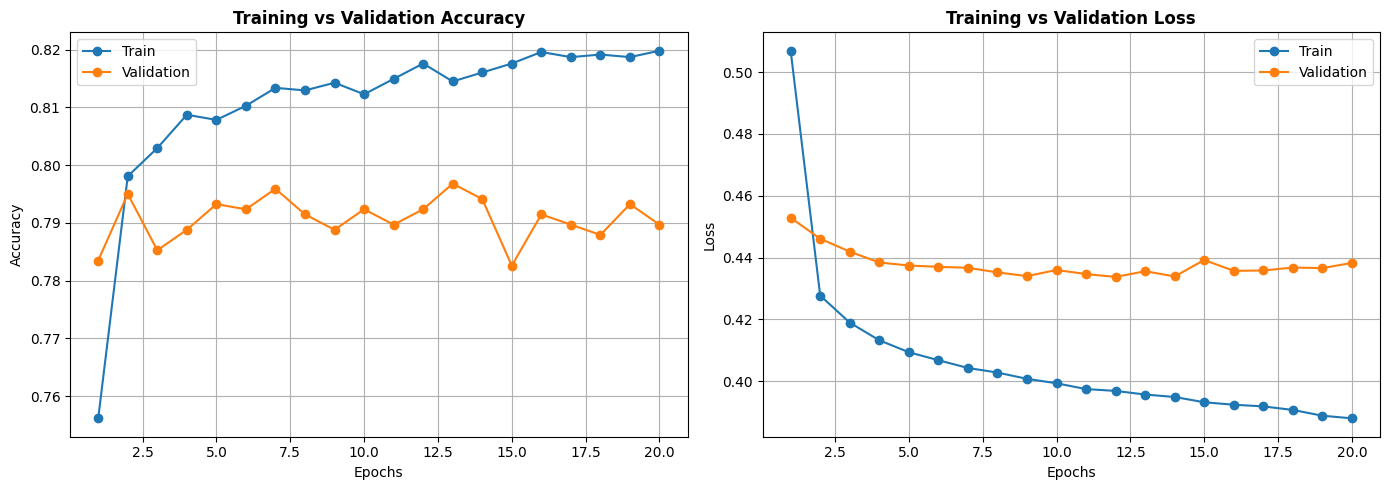

In [ ]:

# ======================
# Extract history
# ======================
acc = history_baseline.history["accuracy"]
val_acc = history_baseline.history["val_accuracy"]

loss = history_baseline.history["loss"]
val_loss = history_baseline.history["val_loss"]

epochs = range(1, len(acc) + 1)

# ======================
# Plot
# ======================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axes[0].plot(epochs, acc, marker='o')
axes[0].plot(epochs, val_acc, marker='o')
axes[0].set_title("Training vs Validation Accuracy", fontweight="bold")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend(["Train", "Validation"])
axes[0].grid()

# Loss Plot
axes[1].plot(epochs, loss, marker='o')
axes[1].plot(epochs, val_loss, marker='o')
axes[1].set_title("Training vs Validation Loss", fontweight="bold")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend(["Train", "Validation"])
axes[1].grid()

plt.tight_layout()
plt.show()

### Baseline Model Analysis

The training accuracy increases steadily, while validation accuracy remains nearly constant around 78–79%. Training loss decreases, but validation loss does not improve.

This indicates overfitting, where the model performs well on training data but fails to generalize to new data.

To improve the model, techniques such as Dropout, L2 regularization, and EarlyStopping can be applied.

## 6. Training & Tuning — Advanced Model

### 6.1 Prepare Data with Class Weights

In [ ]:
# ================================
# PREPARE DATA FOR ADVANCED MODEL
# ================================

X = df.drop("Churn", axis=1).values
y = df["Churn"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, weights))

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Class weights:", class_weights)

X_train: (5634, 24)
X_test : (1409, 24)
Class weights: {np.int64(0): np.float64(0.6805991785455424), np.int64(1): np.float64(1.8842809364548494)}


## 5. Hyperparameter Tuning with Keras Tuner

**المشكلة:** Recall منخفض رغم الـ Grid Search اليدوي.

**الحل:** Keras Tuner مع objective مخصص على `val_recall` + ضبط الـ Threshold.

In [ ]:
!pip install keras-tuner -q
print('Keras Tuner installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.2 MB/s eta 0:00:00
Keras Tuner installed


In [ ]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
print(f'Keras Tuner: {kt.__version__}')
print(f'TensorFlow: {tf.__version__}')

Keras Tuner: 1.4.8
TensorFlow: 2.19.0


### 5.1 Model Builder — يبحث عن أفضل HPs لرفع الـ Recall

In [ ]:
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    l2_val = hp.Choice('l2', values=[0.0001, 0.001, 0.01])

    # Layer 1
    model.add(layers.Dense(
        units=hp.Int('units_l1', min_value=64, max_value=256, step=64),
        activation='relu',
        kernel_regularizer=regularizers.l2(l2_val)
    ))
    model.add(layers.Dropout(hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1)))

    # Layer 2
    model.add(layers.Dense(
        units=hp.Int('units_l2', min_value=32, max_value=128, step=32),
        activation='relu',
        kernel_regularizer=regularizers.l2(l2_val)
    ))
    model.add(layers.Dropout(hp.Float('dropout_2', min_value=0.1, max_value=0.4, step=0.1)))

    # Layer 3
    model.add(layers.Dense(
        units=hp.Int('units_l3', min_value=16, max_value=64, step=16),
        activation='relu'
    ))

    model.add(layers.Dense(1, activation='sigmoid'))

    opt_choice = hp.Choice('optimizer', values=['adam', 'rmsprop', 'sgd'])
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    if opt_choice == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
    elif opt_choice == 'rmsprop':
        opt = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        opt = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.Recall(name='recall'), keras.metrics.AUC(name='auc')]
    )
    return model

### 5.2 إعداد Tuner — الهدف: تعظيم `val_recall`

> لأن الـ Churn dataset غير متوازن، تعظيم الـ Recall مباشرةً أفضل من تعظيم الـ Accuracy.

In [ ]:
import os, shutil

if os.path.exists('kt_recall_dir'):
    shutil.rmtree('kt_recall_dir')

tuner = kt.Hyperband(
    build_model,
    objective=kt.Objective('val_recall', direction='max'),
    max_epochs=30,
    factor=3,
    directory='kt_recall_dir',
    project_name='churn_recall',
    overwrite=True
)

tuner.search_space_summary()

Search space summary
Default search space size: 8
l2 (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.001, 0.01], 'ordered': True}
units_l1 (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 64, 'sampling': 'linear'}
dropout_1 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units_l2 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
dropout_2 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
units_l3 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 64, 'step': 16, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'sgd'], 'ordered': False}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log

### 5.3 تشغيل البحث مع Class Weights

In [ ]:
early_stop = EarlyStopping(
    monitor='val_recall',
    patience=5,
    mode='max',
    restore_best_weights=True
)

print('بدء البحث — الهدف: رفع الـ Recall...')
print('='*60)

tuner.search(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=0
)

print('\nانتهى البحث!')

بدء البحث — الهدف: رفع الـ Recall...

انتهى البحث!


## 6. أفضل Hyperparameters

In [ ]:
best_hps_list = tuner.get_best_hyperparameters(num_trials=3)

print('='*60)
print('أفضل 3 مجموعات Hyperparameters (مرتّبة حسب Recall):')
print('='*60)

for rank, hp in enumerate(best_hps_list, 1):
    print(f'\nالترتيب #{rank}:')
    print(f'  Optimizer:     {hp.get("optimizer")}')
    print(f'  Learning Rate: {hp.get("learning_rate"):.6f}')
    print(f'  L2:            {hp.get("l2")}')
    print(f'  Units L1-L3:   {hp.get("units_l1")} / {hp.get("units_l2")} / {hp.get("units_l3")}')
    print(f'  Dropout 1/2:   {hp.get("dropout_1"):.1f} / {hp.get("dropout_2"):.1f}')

أفضل 3 مجموعات Hyperparameters (مرتّبة حسب Recall):

الترتيب #1:
  Optimizer:     sgd
  Learning Rate: 0.000226
  L2:            0.0001
  Units L1-L3:   64 / 128 / 64
  Dropout 1/2:   0.4 / 0.1

الترتيب #2:
  Optimizer:     sgd
  Learning Rate: 0.000226
  L2:            0.0001
  Units L1-L3:   64 / 128 / 64
  Dropout 1/2:   0.4 / 0.1

الترتيب #3:
  Optimizer:     sgd
  Learning Rate: 0.000175
  L2:            0.01
  Units L1-L3:   192 / 128 / 16
  Dropout 1/2:   0.2 / 0.2


## 7. تدريب أفضل نموذج بالكامل

In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model_kt = tuner.hypermodel.build(best_hps)

print('هيكل أفضل نموذج:')
best_model_kt.summary()

history_kt = best_model_kt.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[EarlyStopping(
        monitor='val_recall',
        patience=7,
        mode='max',
        restore_best_weights=True
    )],
    verbose=1
)

هيكل أفضل نموذج:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,241 (71.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6335 - auc: 0.5024 - loss: 0.7110 - recall: 0.1992 - val_accuracy: 0.6371 - val_auc: 0.5544 - val_loss: 0.6859 - val_recall: 0.2746
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6268 - auc: 0.5817 - loss: 0.6982 - recall: 0.3767 - val_accuracy: 0.6380 - val_auc: 0.6675 - val_loss: 0.6849 - val_recall: 0.5898
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6272 - auc: 0.6240 - loss: 0.6911 - recall: 0.4850 - val_accuracy: 0.6371 - val_auc: 0.7312 - val_loss: 0.6820 - val_recall: 0.7559
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6439 - auc: 0.6875 - loss: 0.6789 - recall: 0.6183 - val_accuracy: 0.6398 - val_auc: 0.7628 - val_loss: 0.6777 - val_recall: 0.8136
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6519 - auc: 0.7229 - loss: 0.6681 - recall: 0.6925 - val_accuracy: 0.6469 - val_auc: 0.7794 - val_loss: 0.6710 - val_recall: 0.8237
Epoch 6/50

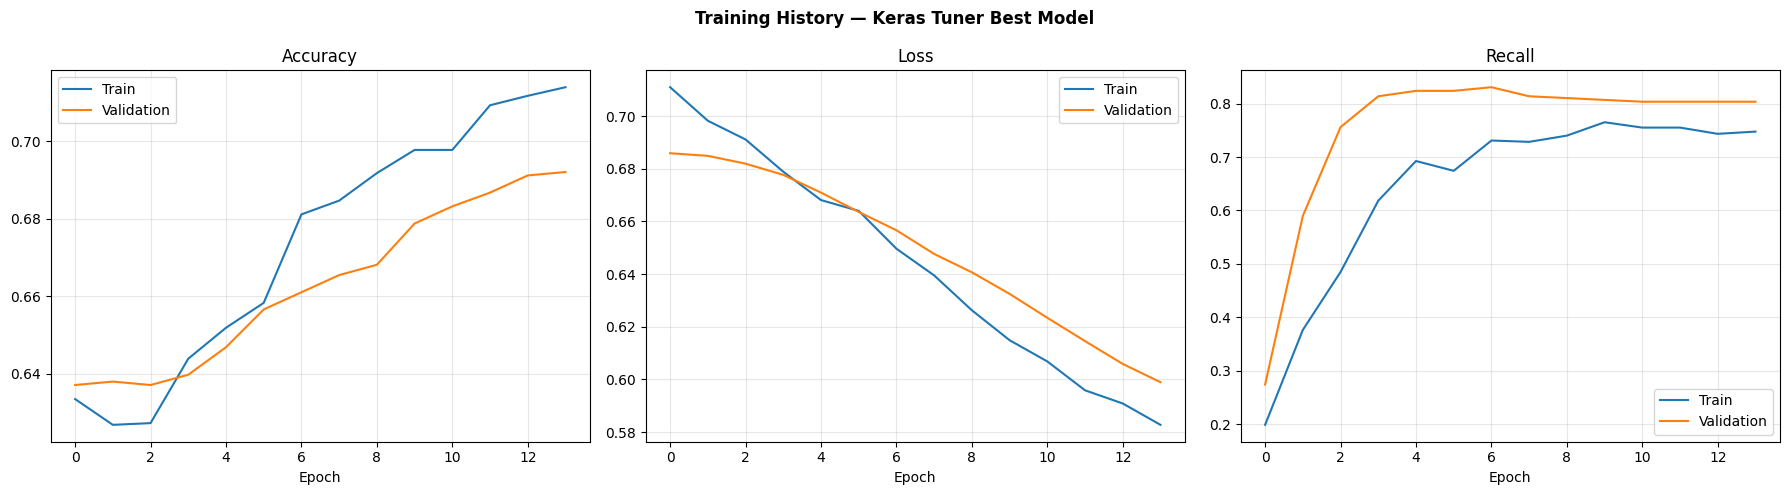

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — Keras Tuner Best Model', fontweight='bold')

pairs = [('accuracy','val_accuracy','Accuracy'),('loss','val_loss','Loss'),('recall','val_recall','Recall')]
for ax, (tr, vl, title) in zip(axes, pairs):
    ax.plot(history_kt.history[tr], label='Train')
    ax.plot(history_kt.history[vl], label='Validation')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. ضبط Threshold لتعظيم الـ Recall

> نبحث عن أفضل threshold يرفع الـ Recall مع الحفاظ على F1 > 0.55.

In [ ]:
from sklearn.metrics import recall_score, f1_score, precision_score

y_prob_kt = best_model_kt.predict(X_test, verbose=0).ravel()

thresholds = np.arange(0.20, 0.55, 0.05)
thr_results = []

for t in thresholds:
    yp = (y_prob_kt >= t).astype(int)
    thr_results.append({
        'Threshold': round(t, 2),
        'Recall':    round(recall_score(y_test, yp), 4),
        'Precision': round(precision_score(y_test, yp, zero_division=0), 4),
        'F1':        round(f1_score(y_test, yp), 4),
    })

thr_df = pd.DataFrame(thr_results)
print(thr_df.to_string(index=False))

valid = thr_df[thr_df['F1'] > 0.55]
if len(valid) > 0:
    best_row = valid.sort_values('Recall', ascending=False).iloc[0]
else:
    best_row = thr_df.sort_values('Recall', ascending=False).iloc[0]

BEST_THRESHOLD = best_row['Threshold']
print(f'\nأفضل Threshold: {BEST_THRESHOLD}')
print(f'  Recall:    {best_row["Recall"]}')
print(f'  Precision: {best_row["Precision"]}')
print(f'  F1:        {best_row["F1"]}')

 Threshold  Recall  Precision     F1
      0.20  1.0000     0.2654 0.4195
      0.25  1.0000     0.2654 0.4195
      0.30  1.0000     0.2654 0.4195
      0.35  1.0000     0.2712 0.4267
      0.40  0.9947     0.2943 0.4542
      0.45  0.9652     0.3599 0.5243
      0.50  0.8235     0.4387 0.5725

أفضل Threshold: 0.5
  Recall:    0.8235
  Precision: 0.4387
  F1:        0.5725


## 9. التقييم النهائي — Baseline vs Keras Tuner

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report)

y_prob_base = baseline_model.predict(X_test, verbose=0).ravel()
y_pred_base = (y_prob_base >= 0.5).astype(int)
y_pred_kt   = (y_prob_kt >= BEST_THRESHOLD).astype(int)

comparison = pd.DataFrame({
    'Model':     ['Baseline', 'Keras Tuner'],
    'Accuracy':  [accuracy_score(y_test, y_pred_base),  accuracy_score(y_test, y_pred_kt)],
    'Precision': [precision_score(y_test, y_pred_base), precision_score(y_test, y_pred_kt, zero_division=0)],
    'Recall':    [recall_score(y_test, y_pred_base),    recall_score(y_test, y_pred_kt)],
    'F1 Score':  [f1_score(y_test, y_pred_base),        f1_score(y_test, y_pred_kt)],
    'ROC-AUC':   [roc_auc_score(y_test, y_prob_base),   roc_auc_score(y_test, y_prob_kt)],
})

print(comparison.to_string(index=False))
print(f'\nClassification Report — Keras Tuner (threshold={BEST_THRESHOLD}):')
print(classification_report(y_test, y_pred_kt))

      Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
   Baseline  0.795600   0.631098 0.553476  0.589744 0.843341
Keras Tuner  0.673527   0.438746 0.823529  0.572491 0.804291

Classification Report — Keras Tuner (threshold=0.5):
              precision    recall  f1-score   support

           0       0.91      0.62      0.74      1035
           1       0.44      0.82      0.57       374

    accuracy                           0.67      1409
   macro avg       0.67      0.72      0.65      1409
weighted avg       0.78      0.67      0.69      1409



## 10. Confusion Matrix & ROC Curve

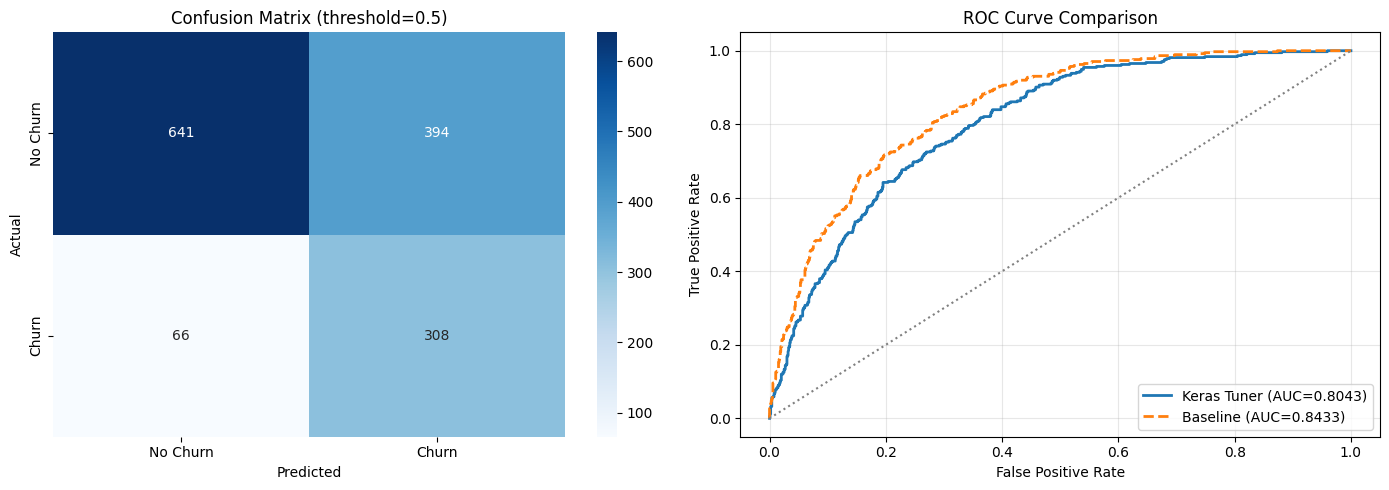

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.metrics import auc as sk_auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_kt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix (threshold={BEST_THRESHOLD})')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# ROC
fpr_kt, tpr_kt, _ = roc_curve(y_test, y_prob_kt)
fpr_b,  tpr_b,  _ = roc_curve(y_test, y_prob_base)

axes[1].plot(fpr_kt, tpr_kt, lw=2, label=f'Keras Tuner (AUC={sk_auc(fpr_kt,tpr_kt):.4f})')
axes[1].plot(fpr_b,  tpr_b,  lw=2, linestyle='--', label=f'Baseline (AUC={sk_auc(fpr_b,tpr_b):.4f})')
axes[1].plot([0,1],[0,1], color='grey', linestyle=':')
axes[1].set_title('ROC Curve Comparison')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

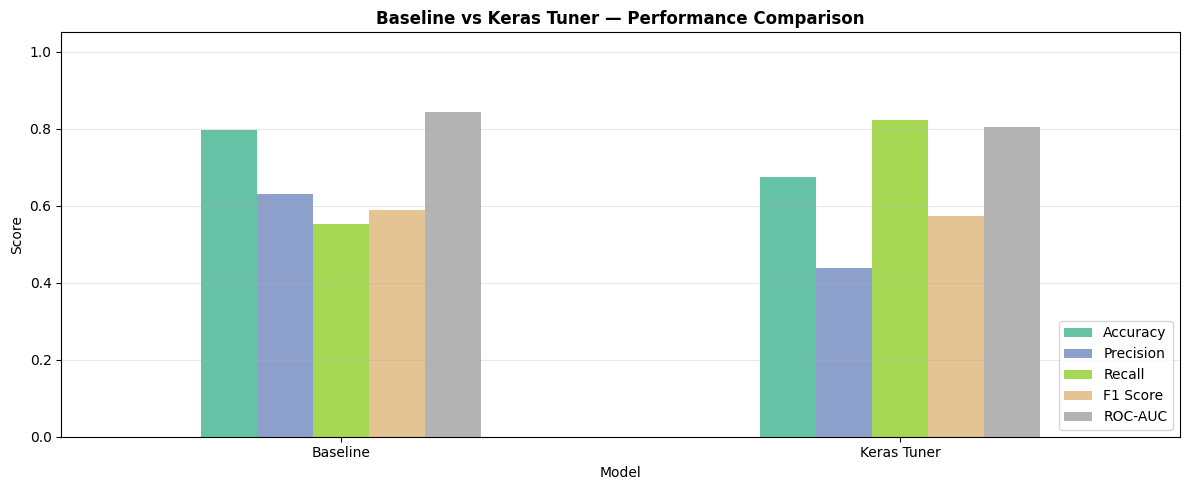

In [ ]:
comparison.set_index('Model').plot(kind='bar', figsize=(12,5), colormap='Set2')
plt.title('Baseline vs Keras Tuner — Performance Comparison', fontweight='bold')
plt.ylabel('Score'); plt.xticks(rotation=0)
plt.legend(loc='lower right'); plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

## 11. حفظ النموذج

In [ ]:
best_model_kt.save('telco_churn_kt_model.h5')
print('تم حفظ النموذج: telco_churn_kt_model.h5')
print(f'Best Threshold: {BEST_THRESHOLD}')

تم حفظ النموذج: telco_churn_kt_model.h5
Best Threshold: 0.5


## 12. Inference Pipeline

In [ ]:
loaded_model_kt = keras.models.load_model('telco_churn_kt_model.h5')

def predict_churn(sample, model=loaded_model_kt, threshold=BEST_THRESHOLD):
    """
    Predict churn for one or multiple samples.
    threshold مضبوط تلقائياً لتعظيم الـ Recall.
    """
    sample = np.array(sample)
    if sample.ndim == 1:
        sample = sample.reshape(1, -1)

    probabilities = model.predict(sample, verbose=0).ravel()
    predictions   = (probabilities >= threshold).astype(int)

    return {
        'probabilities':  probabilities,
        'predictions':    predictions,
        'threshold_used': threshold
    }

example = predict_churn(X_test[0])
print('مثال على التنبؤ:')
print(example)

مثال على التنبؤ:
{'probabilities': array([0.38220218], dtype=float32), 'predictions': array([0]), 'threshold_used': np.float64(0.5)}
